In [110]:
import pickle
import sys
from pathlib import Path
import numpy as np
sys.path.append("..")

import pandas as pd

In [111]:
# ============================================================
# CONFIGURATION - Update this path to your data directory
# ============================================================

DATA_DIR = Path('../syndrome_data_513_2_3_hop/')  # <-- [[5,1,3]] syndrome data

MEASUREMENTS_FILE = DATA_DIR / 'measurements.pkl'
GRAPH_FILE = DATA_DIR / 'graph.pkl'
GROUND_TRUTH_FILE = DATA_DIR / 'ground_truth.pkl'
INFERRED_PARAMETERS_FILE = DATA_DIR / 'inferred_params_independent.pkl'

# Verify files exist
print("Checking input files:")
for f in [MEASUREMENTS_FILE, GRAPH_FILE, GROUND_TRUTH_FILE, INFERRED_PARAMETERS_FILE]:
    status = "✓" if f.exists() else "✗"
    print(f"  {status} {f.name}: {f.exists()}")

Checking input files:
  ✓ measurements.pkl: True
  ✓ graph.pkl: True
  ✓ ground_truth.pkl: True
  ✓ inferred_params_independent.pkl: True


In [112]:
class TimeAwareMeasurement:
    """Data class for syndrome measurements with timing information."""
    def __init__(self, path_edges, histogram, duration, latency_stats=None, code_type='513'):
        """
        :param path_edges: List of tuples representing the path, e.g., [(0,1), (1,2)]
        :param histogram: A 16-dimensional numpy array of syndrome counts for [[5,1,3]] code.
        :param duration: The duration or average latency of this measurement (seconds).
        :param latency_stats: A dictionary with 'max', 'std', 'count'.
        :param code_type: String indicating the code type, e.g., '513'.
        """
        self.path_edges = path_edges
        self.histogram = histogram
        self.duration = duration
        self.latency_stats = latency_stats
        self.code_type = code_type

In [113]:
# ============================================================
# LOAD PICKLE FILES
# ============================================================

with open(MEASUREMENTS_FILE, 'rb') as f:
    measurements = pickle.load(f)

with open(GRAPH_FILE, 'rb') as f:
    graph = pickle.load(f)

with open(GROUND_TRUTH_FILE, 'rb') as f:
    ground_truth = pickle.load(f)

# Load inferred parameters (required - will error if not found)
with open(INFERRED_PARAMETERS_FILE, 'rb') as f:
    inferred_params_raw = pickle.load(f)
# Normalize format: convert [px, py, pz] list to dict format
inferred_params = {}
for edge, rates in inferred_params_raw.items():
    if isinstance(rates, list):
        inferred_params[edge] = {'px': rates[0], 'py': rates[1], 'pz': rates[2], 'pi': 1.0 - sum(rates)}
    else:
        inferred_params[edge] = rates
print(f"Loaded Inferred Parameters for {len(inferred_params)} edges")

# Normalize ground truth format
ground_truth_normalized = {}
for edge, rates in ground_truth.items():
    if isinstance(rates, list):
        ground_truth_normalized[edge] = {'px': rates[0], 'py': rates[1], 'pz': rates[2], 'pi': 1.0 - sum(rates)}
    else:
        ground_truth_normalized[edge] = rates

print(f"Loaded {len(measurements)} syndrome measurements")
print(f"Loaded graph with {len(graph.nodes)} nodes and {len(graph.edges)} edges")
print(f"Loaded Ground Truth for {len(ground_truth_normalized)} edges")

Loaded Inferred Parameters for 7 edges
Loaded 24 syndrome measurements
Loaded graph with 6 nodes and 7 edges
Loaded Ground Truth for 7 edges


In [114]:
# ============================================================
# DISPLAY INFERRED PARAMETERS (px, py, pz, pi)
# ============================================================

params_to_display = inferred_params
params_source = "Inferred"

params_data = []
for edge, rates in params_to_display.items():
    params_data.append({
        'Edge': str(edge),
        'px': rates['px'],
        'py': rates['py'],
        'pz': rates['pz'],
        'pi': rates['pi'],
        'total_error': rates['px'] + rates['py'] + rates['pz'],
    })

df_params = pd.DataFrame(params_data)

styled_params = (df_params
    .style
    .format({col: '{:.4f}' for col in ['px', 'py', 'pz', 'pi', 'total_error']})
    .set_caption(f'{params_source} Parameters Summary (px, py, pz, pi)')
    .background_gradient(subset=['total_error'], cmap='YlOrRd', vmin=0, vmax=0.1)
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#4a4a4a'), ('color', 'white'), ('padding', '10px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('padding', '8px'), ('text-align', 'center')]},
        {'selector': 'tr:hover', 'props': [('background-color', '#f5f5f5')]},
    ])
)

display(styled_params)

,Edge,px,py,pz,pi,total_error
0,"(0, 1)",0.0068,0.0069,0.0075,0.9788,0.0212
1,"(0, 3)",0.0050,0.0011,0.0061,0.9877,0.0123
2,"(1, 2)",0.0032,0.0034,0.0063,0.9871,0.0129
3,"(1, 4)",0.0052,0.0018,0.0058,0.9872,0.0128
4,"(2, 5)",0.0015,0.0017,0.0094,0.9874,0.0126
5,"(3, 4)",0.0051,0.0072,0.0079,0.9798,0.0202
6,"(4, 5)",0.0322,0.0369,0.0396,0.8914,0.1086


## [[5,1,3]] Code Syndrome Mapping

The [[5,1,3]] perfect code has 4 stabilizer generators:
- S1: XZZXI
- S2: IXZZX
- S3: XIXZZ
- S4: ZXIXZ

Each stabilizer measurement yields a single bit (0 or 1), giving a 4-bit syndrome with 16 possible outcomes.

**Syndrome calculation**: For a Pauli error E on qubit q, syndrome bit s_i = 1 iff E anticommutes with S_i.

**Anticommutation rules**:
- X anticommutes with Z (not I, X, Y)
- Y anticommutes with both X and Z
- Z anticommutes with X (not I, Y, Z)
- I commutes with everything

In [115]:
# ============================================================
# [[5,1,3]] STABILIZER SYNDROME MAPPING
# ============================================================
from typing import List, Tuple, Dict

# [[5,1,3]] stabilizers
STABILIZERS_513 = [
    "XZZXI",  # S1
    "IXZZX",  # S2
    "XIXZZ",  # S3
    "ZXIXZ",  # S4
]

def anticommutes(pauli1: str, pauli2: str) -> bool:
    """
    Check if two single-qubit Paulis anticommute.
    X anticommutes with Z, Y anticommutes with X and Z.
    """
    if pauli1 == 'I' or pauli2 == 'I':
        return False
    if pauli1 == pauli2:
        return False
    # X-Z, Z-X, X-Y, Y-X, Y-Z, Z-Y all anticommute
    return True


def compute_syndrome_513(error_type: str, qubit: int) -> int:
    """
    Compute the 4-bit syndrome for a single-qubit Pauli error on the [[5,1,3]] code.
    
    Args:
        error_type: 'I', 'X', 'Y', or 'Z'
        qubit: Qubit index (0-4)
    
    Returns:
        Integer syndrome (0-15) representing the 4-bit measurement outcome
    """
    if error_type == 'I':
        return 0
    
    syndrome = 0
    for stab_idx, stabilizer in enumerate(STABILIZERS_513):
        stab_pauli = stabilizer[qubit]
        if anticommutes(error_type, stab_pauli):
            syndrome |= (1 << stab_idx)  # Set bit stab_idx
    
    return syndrome


# Build syndrome lookup table
SYNDROME_TABLE_513 = {}
for error in ['I', 'X', 'Y', 'Z']:
    for qubit in range(5):
        syndrome = compute_syndrome_513(error, qubit)
        SYNDROME_TABLE_513[(error, qubit)] = syndrome

print("[[5,1,3]] Syndrome Table:")
print("-" * 50)
print(f"{'Error':<8} {'Qubit':<8} {'Syndrome (binary)':<20} {'Syndrome (int)'}")
print("-" * 50)
for (error, qubit), syndrome in SYNDROME_TABLE_513.items():
    print(f"{error:<8} {qubit:<8} {bin(syndrome)[2:].zfill(4):<20} {syndrome}")

[[5,1,3]] Syndrome Table:
--------------------------------------------------
Error    Qubit    Syndrome (binary)    Syndrome (int)
--------------------------------------------------
I        0        0000                 0
I        1        0000                 0
I        2        0000                 0
I        3        0000                 0
I        4        0000                 0
X        0        1000                 8
X        1        0001                 1
X        2        0011                 3
X        3        0110                 6
X        4        1100                 12
Y        0        1101                 13
Y        1        1011                 11
Y        2        0111                 7
Y        3        1111                 15
Y        4        1110                 14
Z        0        0101                 5
Z        1        1010                 10
Z        2        0100                 4
Z        3        1001                 9
Z        4        0010           

In [116]:
# ============================================================
# PAULI COMPOSITION (same as before - code-agnostic)
# ============================================================

def pauli_compose(state: np.ndarray, edge_probs: np.ndarray) -> np.ndarray:
    """
    Compose accumulated Pauli state with edge's Pauli channel.
    
    Pauli multiplication rules (ignoring phase):
    - I*I=I, X*X=I, Y*Y=I, Z*Z=I
    - I*X=X, X*I=X, Y*Z=X, Z*Y=X
    - I*Y=Y, Y*I=Y, X*Z=Y, Z*X=Y
    - I*Z=Z, Z*I=Z, X*Y=Z, Y*X=Z
    
    Args:
        state: [pI, pX, pY, pZ] accumulated Pauli distribution
        edge_probs: [pX, pY, pZ] edge error probabilities (pI computed as 1 - sum)
    
    Returns:
        New [pI, pX, pY, pZ] state after applying edge channel
    """
    pi, px, py, pz = state[0], state[1], state[2], state[3]
    e_px, e_py, e_pz = edge_probs[0], edge_probs[1], edge_probs[2]
    e_pi = 1.0 - e_px - e_py - e_pz
    
    # Apply Pauli composition rules
    new_pi = pi*e_pi + px*e_px + py*e_py + pz*e_pz
    new_px = pi*e_px + px*e_pi + py*e_pz + pz*e_py
    new_py = pi*e_py + py*e_pi + px*e_pz + pz*e_px
    new_pz = pi*e_pz + pz*e_pi + px*e_py + py*e_px
    
    return np.array([new_pi, new_px, new_py, new_pz])


def get_edge_pauli_probs(edge: Tuple[int, int], params: Dict) -> np.ndarray:
    """
    Get Pauli error probabilities [px, py, pz] for an edge.
    
    Args:
        edge: Edge tuple (may need sorting)
        params: Parameter dictionary with {edge: {'px', 'py', 'pz', 'pi'}}
    
    Returns:
        np.array([px, py, pz])
    """
    edge_key = tuple(sorted(edge))
    edge_data = params.get(edge_key)
    
    if edge_data is None:
        raise KeyError(f"No parameters for edge {edge_key}")
    
    return np.array([edge_data['px'], edge_data['py'], edge_data['pz']])


print("Pauli composition functions defined.")

Pauli composition functions defined.


In [117]:
# ============================================================
# [[5,1,3]] SYNDROME PREDICTION
# ============================================================

def pauli_to_syndrome_513(state: np.ndarray) -> np.ndarray:
    """
    Map accumulated Pauli state to 16-element syndrome distribution for [[5,1,3]] code.
    
    For the [[5,1,3]] code:
    - 5 qubits, 4 stabilizers → 16 possible syndromes
    - Each single-qubit Pauli error maps to a specific syndrome
    - We assume errors are i.i.d. across the 5 qubits with the same Pauli distribution
    
    Args:
        state: [pI, pX, pY, pZ] accumulated Pauli distribution per qubit
    
    Returns:
        16-element syndrome probability distribution
    """
    pi, px, py, pz = state[0], state[1], state[2], state[3]
    
    # Initialize syndrome distribution
    syndrome_probs = np.zeros(16)
    
    # For each qubit and each possible error type, accumulate syndrome probabilities
    # We use the approximation that at most one error occurs (valid for small error rates)
    
    # Probability of no error on any qubit (approximately)
    # P(no error) ≈ pi^5 for i.i.d. errors
    p_no_error = pi ** 5
    syndrome_probs[0] = p_no_error
    
    # Single-qubit errors
    for qubit in range(5):
        for error, p_error in [('X', px), ('Y', py), ('Z', pz)]:
            # Probability of this specific error on this qubit, no errors elsewhere
            # P(error on qubit q) ≈ p_error * pi^4
            p_single = p_error * (pi ** 4)
            syndrome = SYNDROME_TABLE_513[(error, qubit)]
            syndrome_probs[syndrome] += p_single
    
    # Normalize to ensure probabilities sum to 1
    # (accounts for multi-qubit errors we're ignoring)
    total = np.sum(syndrome_probs)
    if total > 0:
        syndrome_probs = syndrome_probs / total
    
    return syndrome_probs


def pauli_to_syndrome_513_exact(state: np.ndarray) -> np.ndarray:
    """
    Exact computation of syndrome distribution for [[5,1,3]] code.
    
    Enumerates all 4^5 = 1024 possible error configurations and computes
    their syndromes exactly. More accurate but slower.
    
    Args:
        state: [pI, pX, pY, pZ] accumulated Pauli distribution per qubit
    
    Returns:
        16-element syndrome probability distribution
    """
    pi, px, py, pz = state[0], state[1], state[2], state[3]
    pauli_probs = {'I': pi, 'X': px, 'Y': py, 'Z': pz}
    paulis = ['I', 'X', 'Y', 'Z']
    
    syndrome_probs = np.zeros(16)
    
    # Enumerate all 4^5 error configurations
    for e0 in paulis:
        for e1 in paulis:
            for e2 in paulis:
                for e3 in paulis:
                    for e4 in paulis:
                        # Compute probability of this configuration
                        prob = pauli_probs[e0] * pauli_probs[e1] * pauli_probs[e2] * pauli_probs[e3] * pauli_probs[e4]
                        
                        # Compute syndrome (XOR of individual syndromes)
                        syndrome = 0
                        for q, e in enumerate([e0, e1, e2, e3, e4]):
                            syndrome ^= SYNDROME_TABLE_513[(e, q)]
                        
                        syndrome_probs[syndrome] += prob
    
    return syndrome_probs


def predict_syndrome_513(path_edges: List[Tuple[int, int]],
                         params: Dict,
                         num_shots: int = 4096,
                         exact: bool = True) -> np.ndarray:
    """
    Predict syndrome histogram for [[5,1,3]] code using Pauli channel composition.
    
    1. Start with identity state [1, 0, 0, 0] (no errors)
    2. Compose Pauli channels for each edge in the path
    3. Convert final Pauli state to syndrome distribution
    
    Args:
        path_edges: List of edge tuples in the path
        params: Dict mapping edge -> {px, py, pz, pi}
        num_shots: Number of shots for histogram scaling
        exact: If True, use exact 4^5 enumeration; if False, use approximation
    
    Returns:
        Predicted histogram (16 elements)
    """
    # Start with identity (no error)
    state = np.array([1.0, 0.0, 0.0, 0.0])  # [pI, pX, pY, pZ]
    
    # Compose Pauli channels for each edge
    for edge in path_edges:
        edge_probs = get_edge_pauli_probs(edge, params)
        state = pauli_compose(state, edge_probs)
    
    # Convert to syndrome distribution
    if exact:
        syndrome_probs = pauli_to_syndrome_513_exact(state)
    else:
        syndrome_probs = pauli_to_syndrome_513(state)
    
    # Scale to histogram counts
    histogram = syndrome_probs * num_shots
    
    return histogram.astype(np.float32)


print("[[5,1,3]] syndrome prediction functions defined.")

[[5,1,3]] syndrome prediction functions defined.


In [118]:
# ============================================================
# DISPLAY SYNDROME MEASUREMENTS (16 outcomes)
# ============================================================

# Generate syndrome labels (0000 through 1111)
SYNDROME_LABELS = [format(i, '04b') for i in range(16)]

measurements_data = []
for measure in measurements:
    hist_norm = measure.histogram / np.sum(measure.histogram)
    row = {
        'Path': str(measure.path_edges),
        'Code': measure.code_type,
        'P(0000)': hist_norm[0],  # No error syndrome
        'P(error)': 1.0 - hist_norm[0],  # Total error probability
    }
    measurements_data.append(row)

df_measurements = pd.DataFrame(measurements_data)

styled_measurements = (df_measurements
    .style
    .format({'P(0000)': '{:.4f}', 'P(error)': '{:.4f}'})
    .set_caption(f'[[5,1,3]] Syndrome Measurements Summary ({len(measurements)} total)')
    .background_gradient(subset=['P(0000)'], cmap='Greens', vmin=0.8, vmax=1.0)
    .background_gradient(subset=['P(error)'], cmap='Reds', vmin=0, vmax=0.2)
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#4a4a4a'), ('color', 'white'), ('padding', '10px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('padding', '8px'), ('text-align', 'center')]},
    ])
)

display(styled_measurements)

,Path,Code,P(0000),P(error)
0,"[(0, 3), (3, 4), (4, 1)]",513,0.8354,0.1646
1,"[(0, 1), (1, 2)]",513,0.8506,0.1494
2,"[(0, 1), (1, 4), (4, 3)]",513,0.7817,0.2183
3,"[(0, 1), (1, 4)]",513,0.7986,0.2014
4,"[(0, 3), (3, 4)]",513,0.8086,0.1914
5,"[(0, 1), (1, 2), (2, 5)]",513,0.7964,0.2036
6,"[(0, 1), (1, 4), (4, 5)]",513,0.4717,0.5283
7,"[(0, 3), (3, 4), (4, 5)]",513,0.4758,0.5242
8,"[(1, 4), (4, 5), (5, 2)]",513,0.5396,0.4604
9,"[(1, 0), (0, 3)]",513,0.8528,0.1472


In [119]:
# ============================================================
# COMPUTE PREDICTED VS OBSERVED SYNDROME HISTOGRAMS
# ============================================================

params_for_prediction = inferred_params
params_source = "Inferred"

# Estimate num_shots from first measurement
NUM_SHOTS = int(np.sum(measurements[0].histogram))

comparison_results = []

for measurement in measurements:
    path_edges = measurement.path_edges
    observed_hist = measurement.histogram
    
    # Predict histogram using Pauli composition
    predicted_hist = predict_syndrome_513(
        path_edges=path_edges,
        params=params_for_prediction,
        num_shots=NUM_SHOTS,
        exact=True
    )
    
    # Normalize both to probabilities
    observed_probs = observed_hist / np.sum(observed_hist)
    predicted_probs = predicted_hist / np.sum(predicted_hist)
    
    # Calculate accumulated Pauli state for this path
    state = np.array([1.0, 0.0, 0.0, 0.0])
    for edge in path_edges:
        edge_probs = get_edge_pauli_probs(edge, params_for_prediction)
        state = pauli_compose(state, edge_probs)
    
    comparison_results.append({
        'Path': str(path_edges),
        'Hops': len(path_edges),
        'pI': state[0],
        'pX': state[1],
        'pY': state[2],
        'pZ': state[3],
        'Pred P(0000)': predicted_probs[0],
        'Obs P(0000)': observed_probs[0],
        'Diff': observed_probs[0] - predicted_probs[0],
    })

df_comparison = pd.DataFrame(comparison_results)

# Style the DataFrame
def color_diff(val):
    """Color differences: green for small, red for large."""
    color = '#c8e6c9' if abs(val) < 0.02 else '#ffcdd2' if abs(val) > 0.05 else '#fff9c4'
    return f'background-color: {color}; color: black'

styled_comparison = (df_comparison
    .style
    .format({
        'pI': '{:.4f}', 'pX': '{:.4f}', 'pY': '{:.4f}', 'pZ': '{:.4f}',
        'Pred P(0000)': '{:.4f}', 'Obs P(0000)': '{:.4f}', 'Diff': '{:+.4f}'
    })
    .set_caption(f'Predicted vs Observed Syndrome (using {params_source} parameters)')
    .map(color_diff, subset=['Diff'])
    .background_gradient(subset=['Pred P(0000)', 'Obs P(0000)'], cmap='Blues', vmin=0.8, vmax=1.0)
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#4a4a4a'), ('color', 'white'), ('padding', '10px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('padding', '8px'), ('text-align', 'center')]},
    ])
)

display(styled_comparison)

,Path,Hops,pI,pX,pY,pZ,Pred P(0000),Obs P(0000),Diff
0,"[(0, 3), (3, 4), (4, 1)]",3,0.9556,0.0150,0.0100,0.0194,0.7969,0.8354,+0.0386
1,"[(0, 1), (1, 2)]",2,0.9663,0.0100,0.0102,0.0136,0.8423,0.8506,+0.0083
2,"[(0, 1), (1, 4), (4, 3)]",3,0.9470,0.0168,0.0156,0.0207,0.7619,0.7817,+0.0199
3,"[(0, 1), (1, 4)]",2,0.9663,0.0119,0.0086,0.0132,0.8426,0.7986,-0.0440
4,"[(0, 3), (3, 4)]",2,0.9678,0.0100,0.0083,0.0138,0.8492,0.8086,-0.0407
5,"[(0, 1), (1, 2), (2, 5)]",3,0.9543,0.0114,0.0118,0.0225,0.7914,0.7964,+0.0050
6,"[(0, 1), (1, 4), (4, 5)]",3,0.8626,0.0425,0.0442,0.0507,0.4797,0.4717,-0.0080
7,"[(0, 3), (3, 4), (4, 5)]",3,0.8639,0.0409,0.0439,0.0513,0.4833,0.4758,-0.0075
8,"[(1, 4), (4, 5), (5, 2)]",3,0.8699,0.0380,0.0398,0.0524,0.5000,0.5396,+0.0396
9,"[(1, 0), (0, 3)]",2,0.9668,0.0117,0.0080,0.0134,0.8449,0.8528,+0.0079


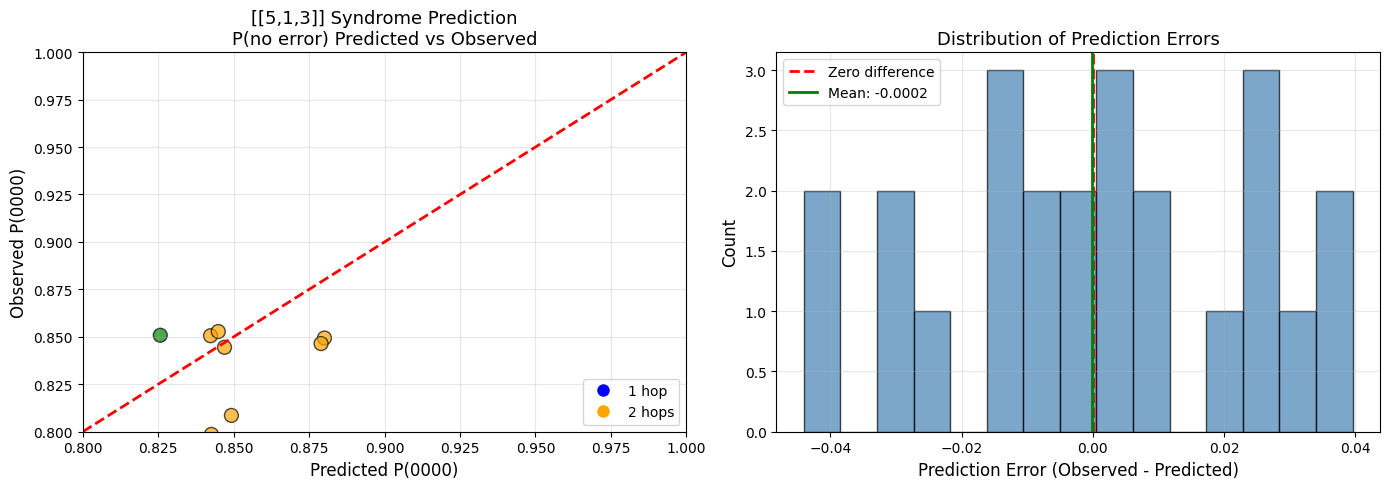


Prediction Quality Summary:
  Mean difference: -0.0002
  Std deviation:   0.0240
  Max absolute:    0.0440
  Correlation:     0.9887


In [120]:
# ============================================================
# VISUALIZE PREDICTIONS: P(0000) Predicted vs Observed
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scatter plot of predicted vs observed P(0000)
ax1 = axes[0]
colors = ['blue' if h == 1 else 'orange' if h == 2 else 'green' for h in df_comparison['Hops']]
scatter = ax1.scatter(df_comparison['Pred P(0000)'], df_comparison['Obs P(0000)'], 
                      c=colors, s=100, alpha=0.7, edgecolors='black')
ax1.plot([0.8, 1], [0.8, 1], 'r--', linewidth=2, label='Perfect prediction')
ax1.set_xlabel('Predicted P(0000)', fontsize=12)
ax1.set_ylabel('Observed P(0000)', fontsize=12)
ax1.set_title('[[5,1,3]] Syndrome Prediction\nP(no error) Predicted vs Observed', fontsize=13)
ax1.set_xlim(0.8, 1.0)
ax1.set_ylim(0.8, 1.0)
ax1.grid(True, alpha=0.3)

# Add legend for hop colors
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='1 hop'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=10, label='2 hops'),
]
ax1.legend(handles=legend_elements, loc='lower right')

# Plot 2: Difference distribution
ax2 = axes[1]
ax2.hist(df_comparison['Diff'], bins=15, edgecolor='black', alpha=0.7, color='steelblue')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero difference')
ax2.axvline(x=df_comparison['Diff'].mean(), color='green', linestyle='-', linewidth=2, 
            label=f'Mean: {df_comparison["Diff"].mean():.4f}')
ax2.set_xlabel('Prediction Error (Observed - Predicted)', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Distribution of Prediction Errors', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nPrediction Quality Summary:")
print(f"  Mean difference: {df_comparison['Diff'].mean():+.4f}")
print(f"  Std deviation:   {df_comparison['Diff'].std():.4f}")
print(f"  Max absolute:    {df_comparison['Diff'].abs().max():.4f}")
corr = np.corrcoef(df_comparison['Pred P(0000)'], df_comparison['Obs P(0000)'])[0, 1]
print(f"  Correlation:     {corr:.4f}")

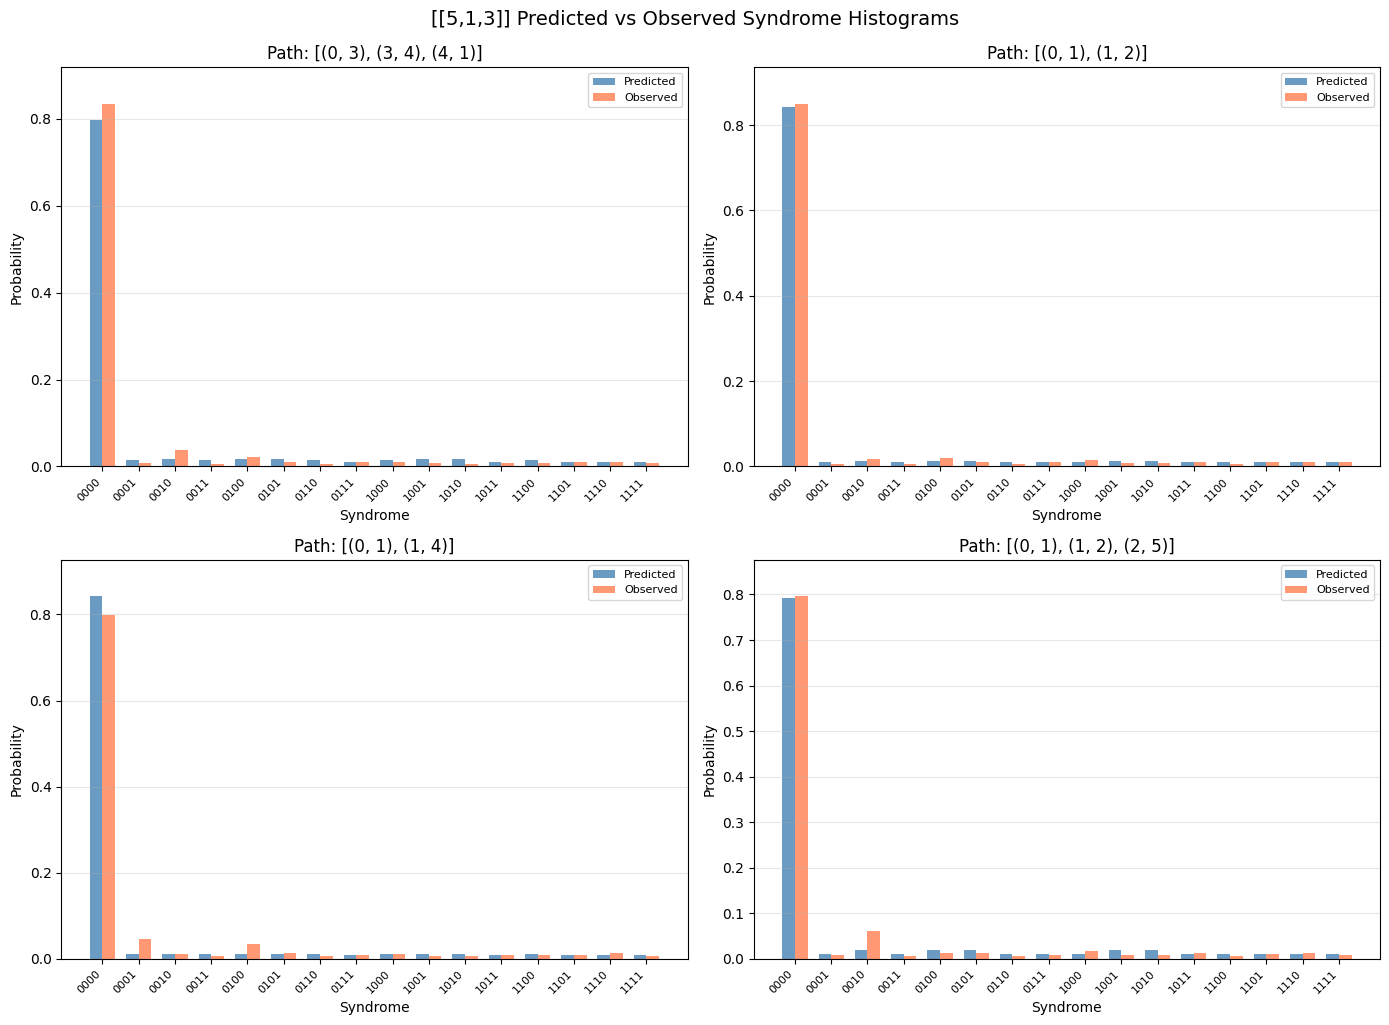

In [121]:
# ============================================================
# FULL 16-BIN HISTOGRAM COMPARISON
# ============================================================

# Select a few representative paths for detailed comparison
sample_indices = [0, 1, 3, 5] if len(measurements) > 5 else list(range(min(4, len(measurements))))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

x = np.arange(16)
width = 0.35

for i, idx in enumerate(sample_indices):
    if i >= len(axes):
        break
    ax = axes[i]
    measurement = measurements[idx]
    
    path_edges = measurement.path_edges
    observed_hist = measurement.histogram
    
    predicted_hist = predict_syndrome_513(
        path_edges=path_edges,
        params=params_for_prediction,
        num_shots=NUM_SHOTS,
        exact=True
    )
    
    observed_probs = observed_hist / np.sum(observed_hist)
    predicted_probs = predicted_hist / np.sum(predicted_hist)
    
    bars1 = ax.bar(x - width/2, predicted_probs, width, label='Predicted', color='steelblue', alpha=0.8)
    bars2 = ax.bar(x + width/2, observed_probs, width, label='Observed', color='coral', alpha=0.8)
    
    ax.set_xlabel('Syndrome')
    ax.set_ylabel('Probability')
    ax.set_title(f'Path: {path_edges}')
    ax.set_xticks(x)
    ax.set_xticklabels(SYNDROME_LABELS, rotation=45, ha='right', fontsize=8)
    ax.legend(fontsize=8)
    ax.set_ylim(0, max(max(predicted_probs), max(observed_probs)) * 1.1)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.suptitle('[[5,1,3]] Predicted vs Observed Syndrome Histograms', fontsize=14, y=1.02)
plt.show()

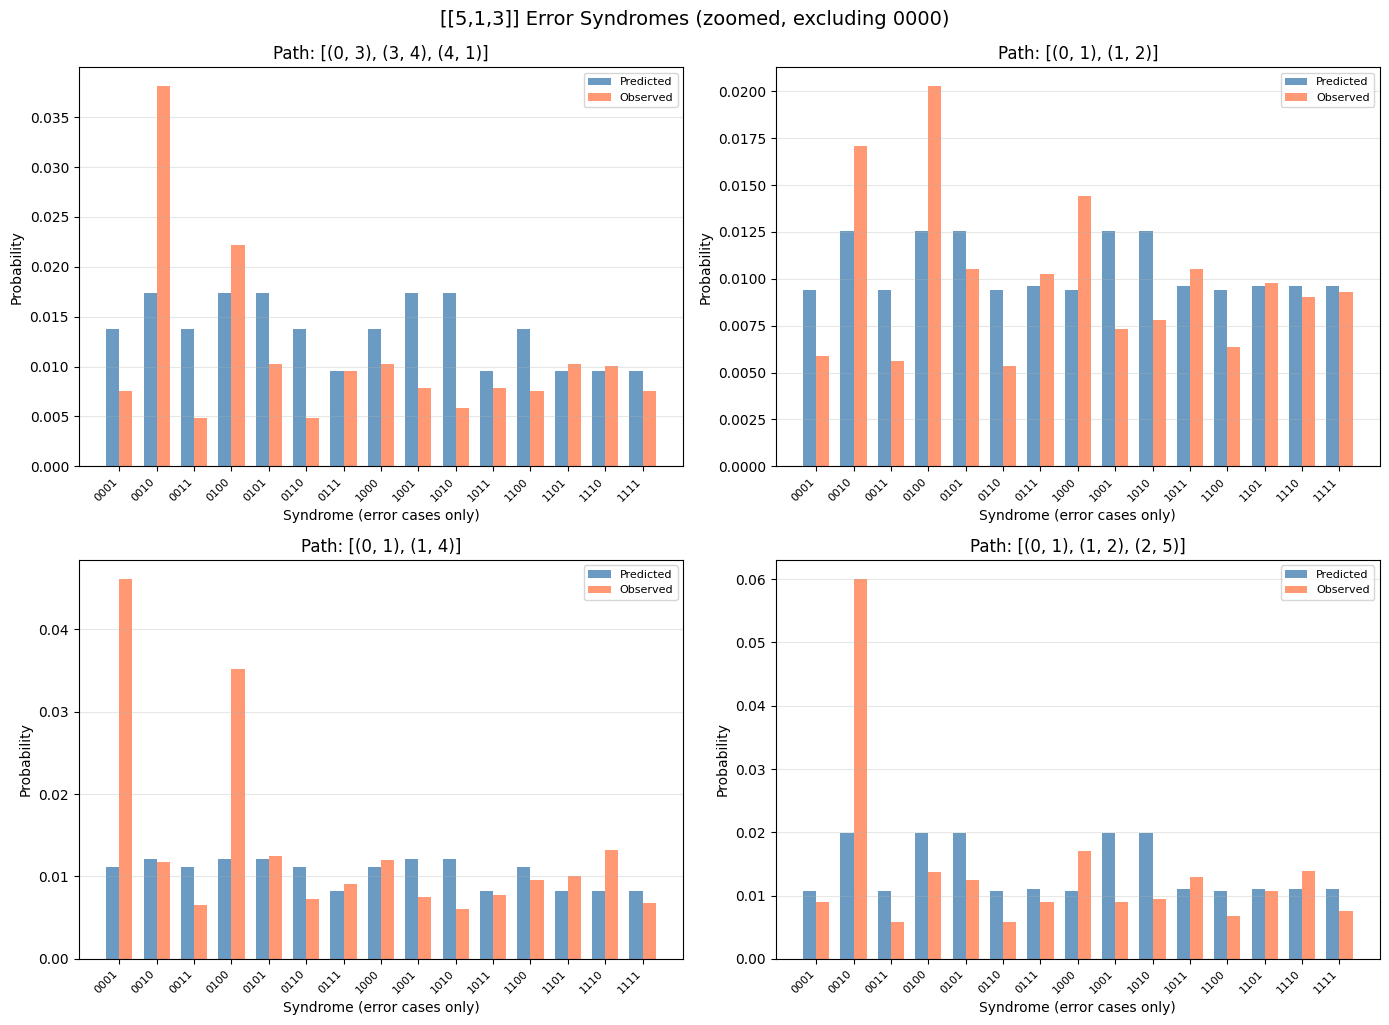

In [122]:
# ============================================================
# ZOOMED VIEW: ERROR SYNDROMES ONLY (excluding 0000)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

x_errors = np.arange(1, 16)  # Syndromes 1-15 (excluding 0000)
width = 0.35

for i, idx in enumerate(sample_indices):
    if i >= len(axes):
        break
    ax = axes[i]
    measurement = measurements[idx]
    
    path_edges = measurement.path_edges
    observed_hist = measurement.histogram
    
    predicted_hist = predict_syndrome_513(
        path_edges=path_edges,
        params=params_for_prediction,
        num_shots=NUM_SHOTS,
        exact=True
    )
    
    observed_probs = observed_hist / np.sum(observed_hist)
    predicted_probs = predicted_hist / np.sum(predicted_hist)
    
    # Plot only error syndromes (1-15)
    bars1 = ax.bar(x_errors - width/2, predicted_probs[1:], width, label='Predicted', color='steelblue', alpha=0.8)
    bars2 = ax.bar(x_errors + width/2, observed_probs[1:], width, label='Observed', color='coral', alpha=0.8)
    
    ax.set_xlabel('Syndrome (error cases only)')
    ax.set_ylabel('Probability')
    ax.set_title(f'Path: {path_edges}')
    ax.set_xticks(x_errors)
    ax.set_xticklabels(SYNDROME_LABELS[1:], rotation=45, ha='right', fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.suptitle('[[5,1,3]] Error Syndromes (zoomed, excluding 0000)', fontsize=14, y=1.02)
plt.show()

In [123]:
# ============================================================
# OVERALL PREDICTION QUALITY METRICS
# ============================================================

def total_variation_distance(p, q):
    """Total Variation Distance: 0.5 * sum(|p_i - q_i|)"""
    return 0.5 * np.sum(np.abs(p - q))

def kl_divergence(p, q, epsilon=1e-10):
    """KL Divergence: sum(p * log(p/q))"""
    p = np.clip(p, epsilon, 1)
    q = np.clip(q, epsilon, 1)
    return np.sum(p * np.log(p / q))

def hellinger_distance(p, q):
    """Hellinger Distance: sqrt(1 - sum(sqrt(p_i * q_i)))"""
    return np.sqrt(1 - np.sum(np.sqrt(p * q)))

metrics_by_hops = {1: [], 2: []}

for measurement in measurements:
    path_edges = measurement.path_edges
    num_hops = len(path_edges)
    observed_hist = measurement.histogram
    
    predicted_hist = predict_syndrome_513(
        path_edges=path_edges,
        params=params_for_prediction,
        num_shots=NUM_SHOTS,
        exact=True
    )
    
    observed_probs = observed_hist / np.sum(observed_hist)
    predicted_probs = predicted_hist / np.sum(predicted_hist)
    
    tvd = total_variation_distance(predicted_probs, observed_probs)
    mse = np.mean((predicted_probs - observed_probs)**2)
    kl = kl_divergence(observed_probs, predicted_probs)
    hellinger = hellinger_distance(predicted_probs, observed_probs)
    
    if num_hops in metrics_by_hops:
        metrics_by_hops[num_hops].append({
            'tvd': tvd, 'mse': mse, 'kl': kl, 'hellinger': hellinger
        })

print("=" * 70)
print("[[5,1,3]] OVERALL PREDICTION QUALITY METRICS")
print(f"Using {params_source} parameters")
print("=" * 70)

for num_hops, metrics_list in metrics_by_hops.items():
    if not metrics_list:
        continue
    print(f"\n{num_hops}-Hop Paths ({len(metrics_list)} measurements):")
    tvds = [m['tvd'] for m in metrics_list]
    mses = [m['mse'] for m in metrics_list]
    kls = [m['kl'] for m in metrics_list]
    hellingers = [m['hellinger'] for m in metrics_list]
    
    print(f"  TVD:       {np.mean(tvds):.4f} ± {np.std(tvds):.4f}")
    print(f"  MSE:       {np.mean(mses):.6f} ± {np.std(mses):.6f}")
    print(f"  KL Div:    {np.mean(kls):.4f} ± {np.std(kls):.4f}")
    print(f"  Hellinger: {np.mean(hellingers):.4f} ± {np.std(hellingers):.4f}")

# Overall metrics
all_metrics = [m for metrics in metrics_by_hops.values() for m in metrics]
print(f"\n{'='*70}")
print(f"OVERALL ({len(all_metrics)} measurements):")
print(f"  Mean TVD:       {np.mean([m['tvd'] for m in all_metrics]):.4f}")
print(f"  Mean MSE:       {np.mean([m['mse'] for m in all_metrics]):.6f}")
print(f"  Mean KL Div:    {np.mean([m['kl'] for m in all_metrics]):.4f}")
print(f"  Mean Hellinger: {np.mean([m['hellinger'] for m in all_metrics]):.4f}")

print("\n" + "-" * 70)
print("Interpretation:")
print("  TVD (Total Variation Distance): 0 = identical, 1 = completely different")
print("  MSE (Mean Squared Error): Lower is better")
print("  KL (KL Divergence): 0 = identical, higher = more different")
print("  Hellinger: 0 = identical, 1 = completely different")

[[5,1,3]] OVERALL PREDICTION QUALITY METRICS
Using Inferred parameters

2-Hop Paths (10 measurements):
  TVD:       0.0451 ± 0.0155
  MSE:       0.000106 ± 0.000085
  KL Div:    0.0289 ± 0.0221
  Hellinger: 0.0741 ± 0.0282

OVERALL (10 measurements):
  Mean TVD:       0.0451
  Mean MSE:       0.000106
  Mean KL Div:    0.0289
  Mean Hellinger: 0.0741

----------------------------------------------------------------------
Interpretation:
  TVD (Total Variation Distance): 0 = identical, 1 = completely different
  MSE (Mean Squared Error): Lower is better
  KL (KL Divergence): 0 = identical, higher = more different
  Hellinger: 0 = identical, 1 = completely different


In [124]:
# ============================================================
# COMPARE SYNDROMES: INFERRED vs GROUND TRUTH vs OBSERVED
# ============================================================

print("Comparing Syndrome Predictions: Inferred vs Ground Truth vs Observed")
print("=" * 80)

comparison_data = []

for measurement in measurements:
    path_edges = measurement.path_edges
    observed_hist = measurement.histogram
    
    # Predict using INFERRED parameters
    predicted_inferred = predict_syndrome_513(
        path_edges=path_edges,
        params=inferred_params,
        num_shots=NUM_SHOTS,
        exact=True
    )
    
    # Predict using GROUND TRUTH parameters
    predicted_gt = predict_syndrome_513(
        path_edges=path_edges,
        params=ground_truth_normalized,
        num_shots=NUM_SHOTS,
        exact=True
    )
    
    # Normalize to probabilities
    observed_probs = observed_hist / np.sum(observed_hist)
    inferred_probs = predicted_inferred / np.sum(predicted_inferred)
    gt_probs = predicted_gt / np.sum(predicted_gt)
    
    # Calculate metrics
    tvd_inferred = total_variation_distance(inferred_probs, observed_probs)
    tvd_gt = total_variation_distance(gt_probs, observed_probs)
    
    comparison_data.append({
        'Path': str(path_edges),
        'Hops': len(path_edges),
        'GT P(0000)': gt_probs[0],
        'Inf P(0000)': inferred_probs[0],
        'Obs P(0000)': observed_probs[0],
        'GT-Obs Diff': gt_probs[0] - observed_probs[0],
        'Inf-Obs Diff': inferred_probs[0] - observed_probs[0],
        'GT TVD': tvd_gt,
        'Inf TVD': tvd_inferred,
        'Better': 'Inferred' if tvd_inferred < tvd_gt else 'GT'
    })

df_comparison_both = pd.DataFrame(comparison_data)

# Style the DataFrame
def color_better(row):
    styles = [''] * len(row)
    if row['Inf TVD'] < row['GT TVD']:
        styles[row.index.get_loc('Better')] = 'background-color: #c8e6c9; color: black'  # green for inferred
    else:
        styles[row.index.get_loc('Better')] = 'background-color: #bbdefb; color: black'  # blue for GT
    return styles

styled_both = (df_comparison_both
    .style
    .format({
        'GT P(0000)': '{:.4f}', 'Inf P(0000)': '{:.4f}', 'Obs P(0000)': '{:.4f}',
        'GT-Obs Diff': '{:+.4f}', 'Inf-Obs Diff': '{:+.4f}',
        'GT TVD': '{:.4f}', 'Inf TVD': '{:.4f}'
    })
    .set_caption('Syndrome Comparison: Ground Truth vs Inferred vs Observed')
    .background_gradient(subset=['GT TVD', 'Inf TVD'], cmap='RdYlGn_r', vmin=0, vmax=0.1)
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', '#4a4a4a'), ('color', 'white'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('padding', '6px'), ('text-align', 'center')]},
    ])
)

display(styled_both)

# Summary statistics
print("\n" + "=" * 80)
print("SUMMARY: Which parameters predict syndromes better?")
print("=" * 80)

inf_wins = sum(1 for d in comparison_data if d['Better'] == 'Inferred')
gt_wins = len(comparison_data) - inf_wins

mean_tvd_inf = np.mean([d['Inf TVD'] for d in comparison_data])
mean_tvd_gt = np.mean([d['GT TVD'] for d in comparison_data])

print(f"\nInferred parameters win: {inf_wins}/{len(comparison_data)} paths")
print(f"Ground Truth wins:       {gt_wins}/{len(comparison_data)} paths")
print(f"\nMean TVD (Inferred):     {mean_tvd_inf:.4f}")
print(f"Mean TVD (Ground Truth): {mean_tvd_gt:.4f}")
print(f"\nOverall better:          {'Inferred' if mean_tvd_inf < mean_tvd_gt else 'Ground Truth'}")

Comparing Syndrome Predictions: Inferred vs Ground Truth vs Observed


,Path,Hops,GT P(0000),Inf P(0000),Obs P(0000),GT-Obs Diff,Inf-Obs Diff,GT TVD,Inf TVD,Better
0,"[(0, 3), (3, 4), (4, 1)]",3,0.7344,0.7969,0.8354,-0.1011,-0.0386,0.1314,0.0654,Inferred
1,"[(0, 1), (1, 2)]",2,0.7722,0.8423,0.8506,-0.0784,-0.0083,0.0877,0.0273,Inferred
2,"[(0, 1), (1, 4), (4, 3)]",3,0.6807,0.7619,0.7817,-0.1010,-0.0199,0.1129,0.0388,Inferred
3,"[(0, 1), (1, 4)]",2,0.7909,0.8426,0.7986,-0.0077,+0.0440,0.0655,0.0668,GT
4,"[(0, 3), (3, 4)]",2,0.7953,0.8492,0.8086,-0.0133,+0.0407,0.0722,0.0652,Inferred
5,"[(0, 1), (1, 2), (2, 5)]",3,0.6122,0.7914,0.7964,-0.1842,-0.0050,0.2187,0.0562,Inferred
6,"[(0, 1), (1, 4), (4, 5)]",3,0.4035,0.4797,0.4717,-0.0681,+0.0080,0.1047,0.0414,Inferred
7,"[(0, 3), (3, 4), (4, 5)]",3,0.4056,0.4833,0.4758,-0.0702,+0.0075,0.0963,0.0335,Inferred
8,"[(1, 4), (4, 5), (5, 2)]",3,0.3742,0.5000,0.5396,-0.1654,-0.0396,0.1654,0.0543,Inferred
9,"[(1, 0), (0, 3)]",2,0.7943,0.8449,0.8528,-0.0584,-0.0079,0.0759,0.0297,Inferred



SUMMARY: Which parameters predict syndromes better?

Inferred parameters win: 23/24 paths
Ground Truth wins:       1/24 paths

Mean TVD (Inferred):     0.0464
Mean TVD (Ground Truth): 0.1187

Overall better:          Inferred


In [125]:
# ============================================================
# METRICS COMPARISON: GROUND TRUTH vs INFERRED (TVD, MSE, KL Div)
# ============================================================

metrics_comparison = []

for measurement in measurements:
    path_edges = measurement.path_edges
    observed_hist = measurement.histogram
    
    # Predict using INFERRED parameters
    predicted_inferred = predict_syndrome_513(
        path_edges=path_edges,
        params=inferred_params,
        num_shots=NUM_SHOTS,
        exact=True
    )
    
    # Predict using GROUND TRUTH parameters
    predicted_gt = predict_syndrome_513(
        path_edges=path_edges,
        params=ground_truth_normalized,
        num_shots=NUM_SHOTS,
        exact=True
    )
    
    # Normalize to probabilities
    observed_probs = observed_hist / np.sum(observed_hist)
    inferred_probs = predicted_inferred / np.sum(predicted_inferred)
    gt_probs = predicted_gt / np.sum(predicted_gt)
    
    # Calculate metrics for Ground Truth
    tvd_gt = total_variation_distance(gt_probs, observed_probs)
    mse_gt = np.mean((gt_probs - observed_probs)**2)
    kl_gt = kl_divergence(observed_probs, gt_probs)
    
    # Calculate metrics for Inferred
    tvd_inf = total_variation_distance(inferred_probs, observed_probs)
    mse_inf = np.mean((inferred_probs - observed_probs)**2)
    kl_inf = kl_divergence(observed_probs, inferred_probs)
    
    metrics_comparison.append({
        'Path': str(path_edges),
        'Hops': len(path_edges),
        'GT TVD': tvd_gt,
        'Inf TVD': tvd_inf,
        'GT MSE': mse_gt,
        'Inf MSE': mse_inf,
        'GT KL': kl_gt,
        'Inf KL': kl_inf,
    })

df_metrics = pd.DataFrame(metrics_comparison)

styled_metrics = (df_metrics
    .style
    .format({
        'GT TVD': '{:.4f}', 'Inf TVD': '{:.4f}',
        'GT MSE': '{:.6f}', 'Inf MSE': '{:.6f}',
        'GT KL': '{:.4f}', 'Inf KL': '{:.4f}'
    })
    .set_caption('Metrics Comparison: Ground Truth vs Inferred (against Observed)')
    .background_gradient(subset=['GT TVD', 'Inf TVD'], cmap='RdYlGn_r', vmin=0, vmax=0.15)
    .background_gradient(subset=['GT MSE', 'Inf MSE'], cmap='RdYlGn_r', vmin=0, vmax=0.001)
    .background_gradient(subset=['GT KL', 'Inf KL'], cmap='RdYlGn_r', vmin=0, vmax=0.2)
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', '#4a4a4a'), ('color', 'white'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('padding', '6px'), ('text-align', 'center')]},
    ])
)

display(styled_metrics)

# Summary statistics
print("\n" + "=" * 80)
print("SUMMARY: Metrics Comparison (Ground Truth vs Inferred)")
print("=" * 80)

# Aggregate by hops
for num_hops in sorted(set(d['Hops'] for d in metrics_comparison)):
    hop_data = [d for d in metrics_comparison if d['Hops'] == num_hops]
    print(f"\n{num_hops}-Hop Paths ({len(hop_data)} measurements):")
    
    print(f"  TVD:  GT = {np.mean([d['GT TVD'] for d in hop_data]):.4f} ± {np.std([d['GT TVD'] for d in hop_data]):.4f}")
    print(f"        Inf = {np.mean([d['Inf TVD'] for d in hop_data]):.4f} ± {np.std([d['Inf TVD'] for d in hop_data]):.4f}")
    
    print(f"  MSE:  GT = {np.mean([d['GT MSE'] for d in hop_data]):.6f} ± {np.std([d['GT MSE'] for d in hop_data]):.6f}")
    print(f"        Inf = {np.mean([d['Inf MSE'] for d in hop_data]):.6f} ± {np.std([d['Inf MSE'] for d in hop_data]):.6f}")
    
    print(f"  KL:   GT = {np.mean([d['GT KL'] for d in hop_data]):.4f} ± {np.std([d['GT KL'] for d in hop_data]):.4f}")
    print(f"        Inf = {np.mean([d['Inf KL'] for d in hop_data]):.4f} ± {np.std([d['Inf KL'] for d in hop_data]):.4f}")

# Overall
print(f"\n{'='*80}")
print(f"OVERALL ({len(metrics_comparison)} measurements):")
print(f"{'='*80}")

mean_tvd_gt = np.mean([d['GT TVD'] for d in metrics_comparison])
mean_tvd_inf = np.mean([d['Inf TVD'] for d in metrics_comparison])
mean_mse_gt = np.mean([d['GT MSE'] for d in metrics_comparison])
mean_mse_inf = np.mean([d['Inf MSE'] for d in metrics_comparison])
mean_kl_gt = np.mean([d['GT KL'] for d in metrics_comparison])
mean_kl_inf = np.mean([d['Inf KL'] for d in metrics_comparison])

print(f"\n  Mean TVD:  Ground Truth = {mean_tvd_gt:.4f},  Inferred = {mean_tvd_inf:.4f}  →  {'Inferred' if mean_tvd_inf < mean_tvd_gt else 'GT'} better by {abs(mean_tvd_gt - mean_tvd_inf):.4f}")
print(f"  Mean MSE:  Ground Truth = {mean_mse_gt:.6f},  Inferred = {mean_mse_inf:.6f}  →  {'Inferred' if mean_mse_inf < mean_mse_gt else 'GT'} better by {abs(mean_mse_gt - mean_mse_inf):.6f}")
print(f"  Mean KL:   Ground Truth = {mean_kl_gt:.4f},  Inferred = {mean_kl_inf:.4f}  →  {'Inferred' if mean_kl_inf < mean_kl_gt else 'GT'} better by {abs(mean_kl_gt - mean_kl_inf):.4f}")

# Count wins
tvd_wins_inf = sum(1 for d in metrics_comparison if d['Inf TVD'] < d['GT TVD'])
mse_wins_inf = sum(1 for d in metrics_comparison if d['Inf MSE'] < d['GT MSE'])
kl_wins_inf = sum(1 for d in metrics_comparison if d['Inf KL'] < d['GT KL'])

print(f"\n  Win counts (Inferred vs GT):")
print(f"    TVD: Inferred wins {tvd_wins_inf}/{len(metrics_comparison)} paths")
print(f"    MSE: Inferred wins {mse_wins_inf}/{len(metrics_comparison)} paths")
print(f"    KL:  Inferred wins {kl_wins_inf}/{len(metrics_comparison)} paths")

,Path,Hops,GT TVD,Inf TVD,GT MSE,Inf MSE,GT KL,Inf KL
0,"[(0, 3), (3, 4), (4, 1)]",3,0.1314,0.0654,0.000764,0.000154,0.0698,0.0327
1,"[(0, 1), (1, 2)]",2,0.0877,0.0273,0.000428,0.000018,0.0310,0.0097
2,"[(0, 1), (1, 4), (4, 3)]",3,0.1129,0.0388,0.000721,0.000048,0.0415,0.0120
3,"[(0, 1), (1, 4)]",2,0.0655,0.0668,0.000139,0.000239,0.0608,0.0526
4,"[(0, 3), (3, 4)]",2,0.0722,0.0652,0.000144,0.000219,0.0634,0.0556
5,"[(0, 1), (1, 2), (2, 5)]",3,0.2187,0.0562,0.002417,0.000131,0.1348,0.0425
6,"[(0, 1), (1, 4), (4, 5)]",3,0.1047,0.0414,0.000429,0.000078,0.0325,0.0137
7,"[(0, 3), (3, 4), (4, 5)]",3,0.0963,0.0335,0.000396,0.000042,0.0235,0.0077
8,"[(1, 4), (4, 5), (5, 2)]",3,0.1654,0.0543,0.001861,0.000126,0.0647,0.0085
9,"[(1, 0), (0, 3)]",2,0.0759,0.0297,0.000262,0.000024,0.0317,0.0141



SUMMARY: Metrics Comparison (Ground Truth vs Inferred)

2-Hop Paths (10 measurements):
  TVD:  GT = 0.0941 ± 0.0319
        Inf = 0.0451 ± 0.0155
  MSE:  GT = 0.000437 ± 0.000397
        Inf = 0.000106 ± 0.000085
  KL:   GT = 0.0503 ± 0.0288
        Inf = 0.0289 ± 0.0221

3-Hop Paths (14 measurements):
  TVD:  GT = 0.1363 ± 0.0411
        Inf = 0.0473 ± 0.0110
  MSE:  GT = 0.001060 ± 0.000752
        Inf = 0.000089 ± 0.000044
  KL:   GT = 0.0632 ± 0.0394
        Inf = 0.0214 ± 0.0155

OVERALL (24 measurements):

  Mean TVD:  Ground Truth = 0.1187,  Inferred = 0.0464  →  Inferred better by 0.0723
  Mean MSE:  Ground Truth = 0.000800,  Inferred = 0.000096  →  Inferred better by 0.000704
  Mean KL:   Ground Truth = 0.0578,  Inferred = 0.0245  →  Inferred better by 0.0333

  Win counts (Inferred vs GT):
    TVD: Inferred wins 23/24 paths
    MSE: Inferred wins 21/24 paths
    KL:  Inferred wins 24/24 paths


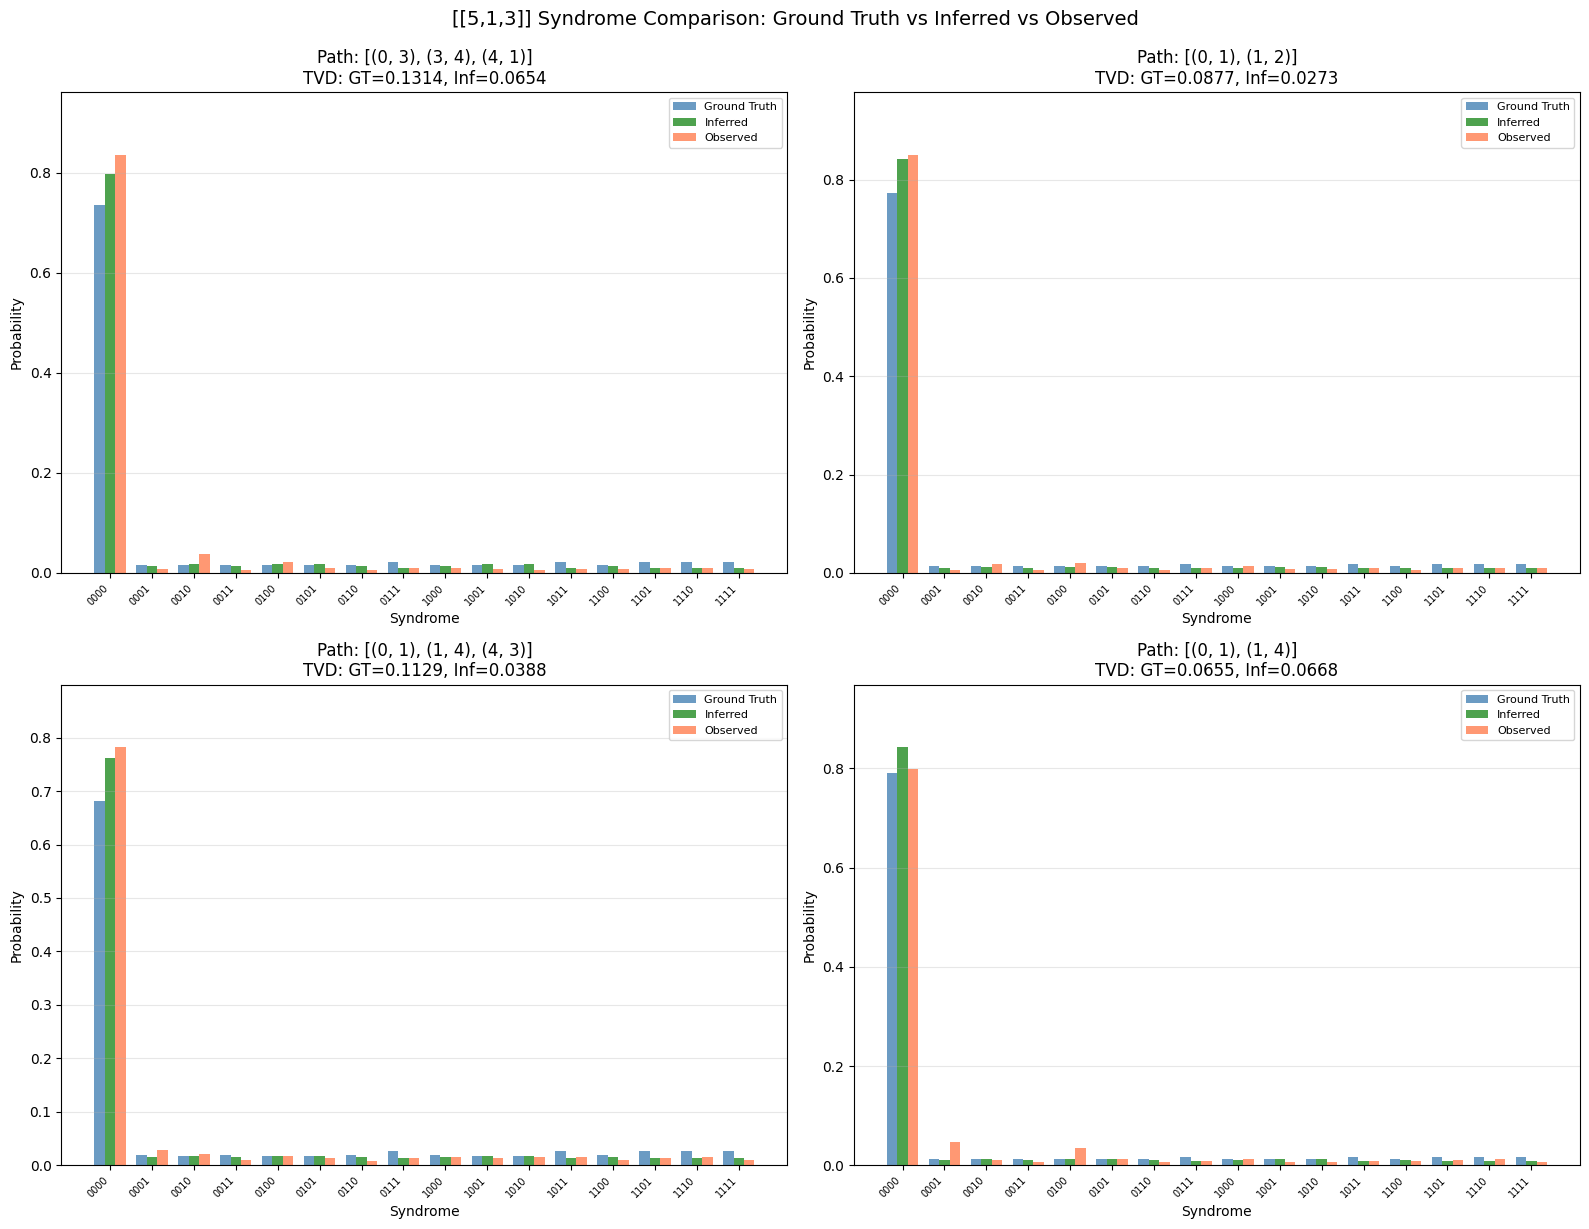

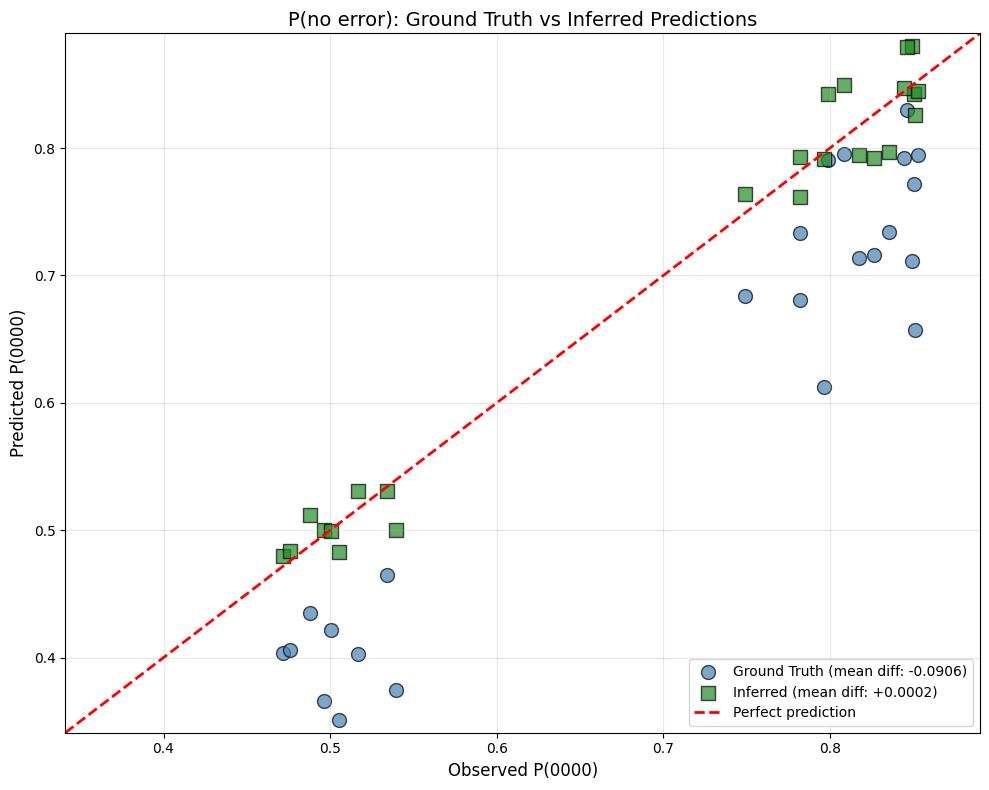

In [126]:
# ============================================================
# VISUALIZATION: INFERRED vs GROUND TRUTH vs OBSERVED SYNDROMES
# ============================================================

# Select sample paths for detailed comparison
sample_indices = [0, 1, 2, 3] if len(measurements) > 3 else list(range(len(measurements)))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

x = np.arange(16)
width = 0.25  # Width for 3 bars

for i, idx in enumerate(sample_indices):
    if i >= len(axes):
        break
    ax = axes[i]
    measurement = measurements[idx]
    
    path_edges = measurement.path_edges
    observed_hist = measurement.histogram
    
    # Predict using both parameter sets
    predicted_inferred = predict_syndrome_513(
        path_edges=path_edges,
        params=inferred_params,
        num_shots=NUM_SHOTS,
        exact=True
    )
    
    predicted_gt = predict_syndrome_513(
        path_edges=path_edges,
        params=ground_truth_normalized,
        num_shots=NUM_SHOTS,
        exact=True
    )
    
    # Normalize
    observed_probs = observed_hist / np.sum(observed_hist)
    inferred_probs = predicted_inferred / np.sum(predicted_inferred)
    gt_probs = predicted_gt / np.sum(predicted_gt)
    
    # Plot 3 bars for each syndrome
    bars1 = ax.bar(x - width, gt_probs, width, label='Ground Truth', color='steelblue', alpha=0.8)
    bars2 = ax.bar(x, inferred_probs, width, label='Inferred', color='forestgreen', alpha=0.8)
    bars3 = ax.bar(x + width, observed_probs, width, label='Observed', color='coral', alpha=0.8)
    
    # Calculate TVDs for title
    tvd_gt = total_variation_distance(gt_probs, observed_probs)
    tvd_inf = total_variation_distance(inferred_probs, observed_probs)
    
    ax.set_xlabel('Syndrome')
    ax.set_ylabel('Probability')
    ax.set_title(f'Path: {path_edges}\nTVD: GT={tvd_gt:.4f}, Inf={tvd_inf:.4f}')
    ax.set_xticks(x)
    ax.set_xticklabels(SYNDROME_LABELS, rotation=45, ha='right', fontsize=7)
    ax.legend(fontsize=8)
    ax.set_ylim(0, max(max(gt_probs), max(inferred_probs), max(observed_probs)) * 1.15)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.suptitle('[[5,1,3]] Syndrome Comparison: Ground Truth vs Inferred vs Observed', 
             fontsize=14, y=1.02)
plt.show()

# Scatter plot: GT prediction vs Inferred prediction (both against observed)
fig, ax = plt.subplots(figsize=(10, 8))

gt_p0000 = [d['GT P(0000)'] for d in comparison_data]
inf_p0000 = [d['Inf P(0000)'] for d in comparison_data]
obs_p0000 = [d['Obs P(0000)'] for d in comparison_data]

ax.scatter(obs_p0000, gt_p0000, s=100, c='steelblue', alpha=0.7, 
           label=f'Ground Truth (mean diff: {np.mean(np.array(gt_p0000) - np.array(obs_p0000)):+.4f})', 
           edgecolors='black', marker='o')
ax.scatter(obs_p0000, inf_p0000, s=100, c='forestgreen', alpha=0.7,
           label=f'Inferred (mean diff: {np.mean(np.array(inf_p0000) - np.array(obs_p0000)):+.4f})',
           edgecolors='black', marker='s')

# Perfect prediction line
lims = [min(min(obs_p0000), min(gt_p0000), min(inf_p0000)) - 0.01,
        max(max(obs_p0000), max(gt_p0000), max(inf_p0000)) + 0.01]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')

ax.set_xlabel('Observed P(0000)', fontsize=12)
ax.set_ylabel('Predicted P(0000)', fontsize=12)
ax.set_title('P(no error): Ground Truth vs Inferred Predictions', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(lims)
ax.set_ylim(lims)

plt.tight_layout()
plt.show()

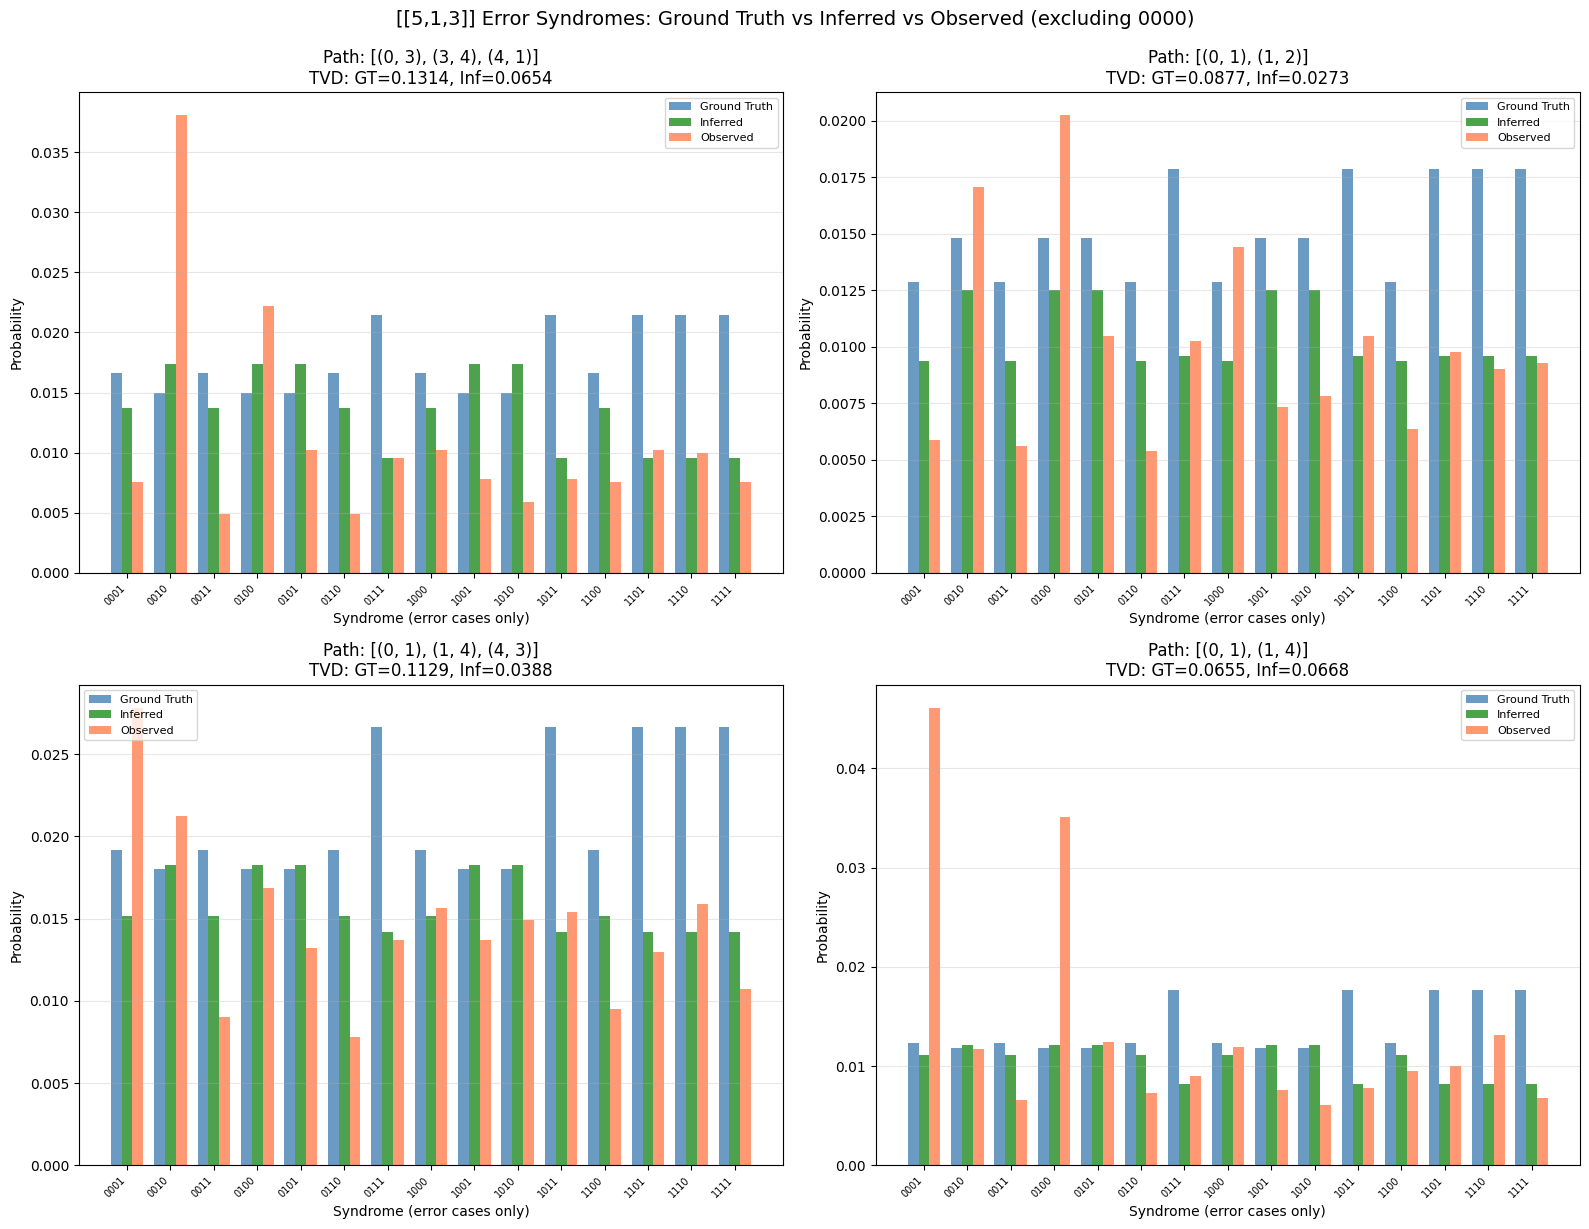

In [127]:
# ============================================================
# VISUALIZATION: INFERRED vs GROUND TRUTH vs OBSERVED (ERROR SYNDROMES ONLY)
# ============================================================
# Same as above but excluding the '0000' syndrome to zoom in on error patterns

# Select sample paths for detailed comparison
sample_indices = [0, 1, 2, 3] if len(measurements) > 3 else list(range(len(measurements)))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

x_errors = np.arange(1, 16)  # Syndromes 1-15 (excluding 0000)
width = 0.25  # Width for 3 bars

for i, idx in enumerate(sample_indices):
    if i >= len(axes):
        break
    ax = axes[i]
    measurement = measurements[idx]
    
    path_edges = measurement.path_edges
    observed_hist = measurement.histogram
    
    # Predict using both parameter sets
    predicted_inferred = predict_syndrome_513(
        path_edges=path_edges,
        params=inferred_params,
        num_shots=NUM_SHOTS,
        exact=True
    )
    
    predicted_gt = predict_syndrome_513(
        path_edges=path_edges,
        params=ground_truth_normalized,
        num_shots=NUM_SHOTS,
        exact=True
    )
    
    # Normalize
    observed_probs = observed_hist / np.sum(observed_hist)
    inferred_probs = predicted_inferred / np.sum(predicted_inferred)
    gt_probs = predicted_gt / np.sum(predicted_gt)
    
    # Plot 3 bars for each error syndrome (excluding 0000)
    bars1 = ax.bar(x_errors - width, gt_probs[1:], width, label='Ground Truth', color='steelblue', alpha=0.8)
    bars2 = ax.bar(x_errors, inferred_probs[1:], width, label='Inferred', color='forestgreen', alpha=0.8)
    bars3 = ax.bar(x_errors + width, observed_probs[1:], width, label='Observed', color='coral', alpha=0.8)
    
    # Calculate TVDs for title
    tvd_gt = total_variation_distance(gt_probs, observed_probs)
    tvd_inf = total_variation_distance(inferred_probs, observed_probs)
    
    ax.set_xlabel('Syndrome (error cases only)')
    ax.set_ylabel('Probability')
    ax.set_title(f'Path: {path_edges}\nTVD: GT={tvd_gt:.4f}, Inf={tvd_inf:.4f}')
    ax.set_xticks(x_errors)
    ax.set_xticklabels(SYNDROME_LABELS[1:], rotation=45, ha='right', fontsize=7)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.suptitle('[[5,1,3]] Error Syndromes: Ground Truth vs Inferred vs Observed (excluding 0000)', 
             fontsize=14, y=1.02)
plt.show()

In [128]:
# ============================================================
# PARAMETER COMPARISON: GROUND TRUTH vs INFERRED
# ============================================================

print("Edge-by-Edge Parameter Comparison:")
print("=" * 80)

param_comparison_data = []
for edge in ground_truth_normalized.keys():
    gt = ground_truth_normalized[edge]
    inf = inferred_params.get(edge, {})
    
    gt_total = gt['px'] + gt['py'] + gt['pz']
    inf_total = inf.get('px', 0) + inf.get('py', 0) + inf.get('pz', 0)
    
    param_comparison_data.append({
        'Edge': str(edge),
        'GT px': gt['px'],
        'Inf px': inf.get('px', np.nan),
        'Δpx': inf.get('px', 0) - gt['px'],
        'GT py': gt['py'],
        'Inf py': inf.get('py', np.nan),
        'Δpy': inf.get('py', 0) - gt['py'],
        'GT pz': gt['pz'],
        'Inf pz': inf.get('pz', np.nan),
        'Δpz': inf.get('pz', 0) - gt['pz'],
        'GT total': gt_total,
        'Inf total': inf_total,
        'Δtotal': inf_total - gt_total,
    })

df_param_comp = pd.DataFrame(param_comparison_data)

styled_param_comp = (df_param_comp
    .style
    .format({col: '{:.5f}' for col in df_param_comp.columns if col != 'Edge'})
    .set_caption('Ground Truth vs Inferred Pauli Error Rates (per edge)')
    .background_gradient(subset=['Δpx', 'Δpy', 'Δpz', 'Δtotal'], cmap='RdYlGn_r', vmin=-0.01, vmax=0.01)
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', '#4a4a4a'), ('color', 'white'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('padding', '6px'), ('text-align', 'center')]},
    ])
)

display(styled_param_comp)

# Summary
mean_abs_diff_px = np.mean([abs(d['Δpx']) for d in param_comparison_data])
mean_abs_diff_py = np.mean([abs(d['Δpy']) for d in param_comparison_data])
mean_abs_diff_pz = np.mean([abs(d['Δpz']) for d in param_comparison_data])
mean_abs_diff_total = np.mean([abs(d['Δtotal']) for d in param_comparison_data])

print(f"\nMean Absolute Differences:")
print(f"  |Δpx|:    {mean_abs_diff_px:.5f}")
print(f"  |Δpy|:    {mean_abs_diff_py:.5f}")
print(f"  |Δpz|:    {mean_abs_diff_pz:.5f}")
print(f"  |Δtotal|: {mean_abs_diff_total:.5f}")

Edge-by-Edge Parameter Comparison:


,Edge,GT px,Inf px,Δpx,GT py,Inf py,Δpy,GT pz,Inf pz,Δpz,GT total,Inf total,Δtotal
0,"(0, 1)",0.00745,0.00683,-0.00061,0.01404,0.00691,-0.00713,0.00891,0.00748,-0.00143,0.03040,0.02122,-0.00917
1,"(0, 3)",0.00403,0.00501,0.00098,0.00623,0.00114,-0.00508,0.00500,0.00612,0.00112,0.01526,0.01228,-0.00298
2,"(1, 2)",0.00671,0.00322,-0.00350,0.00647,0.00339,-0.00308,0.00769,0.00628,-0.00141,0.02087,0.01289,-0.00799
3,"(1, 4)",0.00610,0.00522,-0.00088,0.00610,0.00176,-0.00435,0.00391,0.00584,0.00194,0.01611,0.01282,-0.00330
4,"(2, 5)",0.01636,0.00147,-0.01489,0.01465,0.00170,-0.01295,0.01538,0.00941,-0.00597,0.04639,0.01257,-0.03381
5,"(3, 4)",0.00891,0.00511,-0.00381,0.01331,0.00721,-0.00610,0.00793,0.00790,-0.00004,0.03015,0.02021,-0.00994
6,"(4, 5)",0.04834,0.03218,-0.01616,0.04663,0.03688,-0.00975,0.03467,0.03957,0.00490,0.12964,0.10862,-0.02101



Mean Absolute Differences:
  |Δpx|:    0.00583
  |Δpy|:    0.00692
  |Δpz|:    0.00240
  |Δtotal|: 0.01260


In [129]:
# ============================================================
# SYNDROME PATTERN ANALYSIS
# ============================================================
# Analyze which syndromes are most common across all measurements

# Aggregate all syndrome counts
total_syndrome_counts = np.zeros(16)
for measurement in measurements:
    total_syndrome_counts += measurement.histogram

total_syndrome_probs = total_syndrome_counts / np.sum(total_syndrome_counts)

# Create DataFrame for analysis
syndrome_analysis = []
for i in range(16):
    # Determine which single-qubit errors map to this syndrome
    error_sources = []
    for error in ['X', 'Y', 'Z']:
        for qubit in range(5):
            if SYNDROME_TABLE_513[(error, qubit)] == i:
                error_sources.append(f"{error}{qubit}")
    
    syndrome_analysis.append({
        'Syndrome': SYNDROME_LABELS[i],
        'Decimal': i,
        'Count': int(total_syndrome_counts[i]),
        'Probability': total_syndrome_probs[i],
        'Error Sources': ', '.join(error_sources) if error_sources else 'No single error',
    })

df_syndrome = pd.DataFrame(syndrome_analysis)

styled_syndrome = (df_syndrome
    .style
    .format({'Probability': '{:.4f}', 'Count': '{:,.0f}'})
    .set_caption('[[5,1,3]] Syndrome Distribution (Aggregated Across All Measurements)')
    .background_gradient(subset=['Probability'], cmap='Blues')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', '#4a4a4a'), ('color', 'white'), ('padding', '10px')]},
        {'selector': 'td', 'props': [('padding', '8px')]},
    ])
)

display(styled_syndrome)

,Syndrome,Decimal,Count,Probability,Error Sources
0,0000,0,"68,887",0.7008,No single error
1,0001,1,"2,809",0.0286,X1
2,0010,2,"3,477",0.0354,Z4
3,0011,3,"1,378",0.0140,X2
4,0100,4,"2,740",0.0279,Z2
5,0101,5,"1,830",0.0186,Z0
6,0110,6,"1,335",0.0136,X3
7,0111,7,"1,725",0.0175,Y2
8,1000,8,"1,995",0.0203,X0
9,1001,9,"1,802",0.0183,Z3


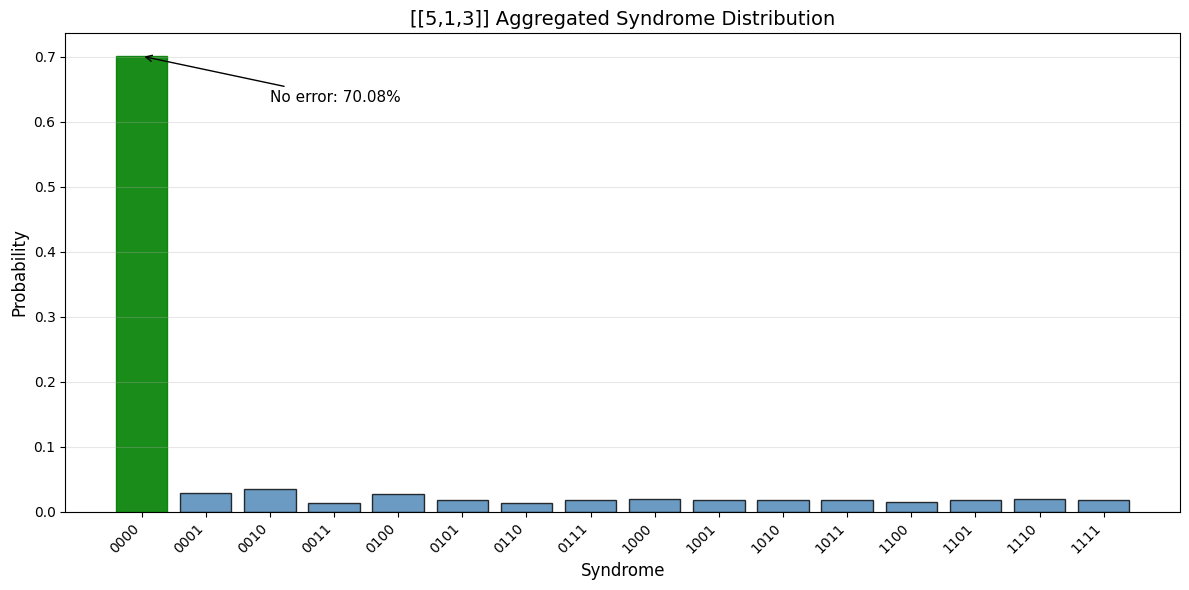


Total measurements: 24
Total shots: 98,304
Overall no-error rate: 70.08%
Overall error rate: 29.92%


In [130]:
# ============================================================
# FINAL VISUALIZATION: Aggregated Syndrome Bar Chart
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(16)
bars = ax.bar(x, total_syndrome_probs, color='steelblue', edgecolor='black', alpha=0.8)

# Highlight the no-error syndrome
bars[0].set_color('green')
bars[0].set_alpha(0.9)

ax.set_xlabel('Syndrome', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('[[5,1,3]] Aggregated Syndrome Distribution', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(SYNDROME_LABELS, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# Add annotation for no-error probability
ax.annotate(f'No error: {total_syndrome_probs[0]:.2%}', 
            xy=(0, total_syndrome_probs[0]), 
            xytext=(2, total_syndrome_probs[0] * 0.9),
            fontsize=11,
            arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.show()

print(f"\nTotal measurements: {len(measurements)}")
print(f"Total shots: {int(np.sum(total_syndrome_counts)):,}")
print(f"Overall no-error rate: {total_syndrome_probs[0]:.2%}")
print(f"Overall error rate: {1 - total_syndrome_probs[0]:.2%}")